<a href="https://colab.research.google.com/github/BU-Spark/ds-ciss-predictive-homlessness/blob/data-cleaning-feature/Pat_Feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


In [2]:
file_path = '/content/Final_Dataset.csv'
data = pd.read_csv(file_path)
data.head()


,Total Population,Median Gross Rent,Median Household Income,Poverty_Rate,Vacancy_Rate,Renter_Household_Rate,Cost_Burdened_Rate,Unemployment_Rate,"Total Year-Round Beds (ES, TH, SH)",Average Temperature,Overall Homeless,Overall Homeless Individuals,Overall Homeless People in Families,Unsheltered Homeless,Sheltered Total Homeless,Overall_Homeless_Per_Capita,Overall_Homeless_Individuals_Per_Capita,Overall_Homeless_People_in_Families_Per_Capita,Unsheltered_Homeless_Per_Capita,Sheltered_Homeless_Per_Capita
0,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,5.5,974.0,696.0,278.0,132.0,842.0,0.003781,0.002702,0.001079,0.000512,0.003268
1,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,0.4,1023.0,695.0,328.0,102.0,921.0,0.003971,0.002698,0.001273,0.000396,0.003575
2,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,-0.2,1267.0,821.0,446.0,157.0,1110.0,0.004918,0.003187,0.001731,0.000609,0.004308
3,257633,56401,3728285,8.298238,7.425172,40.858279,42.153397,7.583368,NaN,1.5,1231.0,740.0,491.0,118.0,1113.0,0.004778,0.002872,0.001906,0.000458,0.004320
4,250934,54926,3573107,8.504627,7.073878,42.293547,42.845948,7.593841,NaN,7.0,1223.0,794.0,429.0,141.0,1082.0,0.004874,0.003164,0.001710,0.000562,0.004312


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6524 entries, 0 to 6523
Data columns (total 20 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Total Population                                6524 non-null   int64  
 1   Median Gross Rent                               6524 non-null   int64  
 2   Median Household Income                         6524 non-null   int64  
 3   Poverty_Rate                                    6524 non-null   float64
 4   Vacancy_Rate                                    6524 non-null   float64
 5   Renter_Household_Rate                           6524 non-null   float64
 6   Cost_Burdened_Rate                              6524 non-null   float64
 7   Unemployment_Rate                               6524 non-null   float64
 8   Total Year-Round Beds (ES, TH, SH)              3777 non-null   float64
 9   Average Temperature                      

## Data Cleaning

In [4]:
data = data.dropna(subset=['Overall_Homeless_Per_Capita'])

# For 'Total Year-Round Beds (ES, TH, SH)' (~42% missing), fill missing with the median.
data['Total Year-Round Beds (ES, TH, SH)'] = data['Total Year-Round Beds (ES, TH, SH)'].fillna(
    data['Total Year-Round Beds (ES, TH, SH)'].median()
)

# For 'Average Temperature' (~1.5% missing), fill missing with the median.
data['Average Temperature'] = data['Average Temperature'].fillna(data['Average Temperature'].median())

# For homeless-related columns, fill missing values with their respective medians.
homeless_cols = [
    'Overall Homeless', 'Overall Homeless Individuals', 'Overall Homeless People in Families',
    'Unsheltered Homeless', 'Sheltered Total Homeless', 'Overall_Homeless_Individuals_Per_Capita',
    'Overall_Homeless_People_in_Families_Per_Capita', 'Unsheltered_Homeless_Per_Capita',
    'Sheltered_Homeless_Per_Capita'
]
for col in homeless_cols:
    data[col] = data[col].fillna(data[col].median())

## Feature Engineering

In [5]:
#Income to Rent Ratio: A measure of housing affordability.
data['Income_Rent_Ratio'] = data['Median Household Income'] / (data['Median Gross Rent'] + 1)



#Economic Vulnerability: Interaction between Unemployment_Rate and Renter_Household_Rate.
data['Economic_Vulnerability'] = data['Unemployment_Rate'] * data['Renter_Household_Rate']


## Splitting data for XGBoost

In [6]:
# Exclude columns that directly capture homelessness to avoid data leakage.
cols_to_exclude = [
    'Median Gross Rent', 'Overall Homeless', 'Overall Homeless Individuals', 'Overall Homeless People in Families', 'Unsheltered Homeless', 'Sheltered Total Homeless', 'Overall_Homeless_Individuals_Per_Capita',
                       'Overall_Homeless_People_in_Families_Per_Capita', 'Unsheltered_Homeless_Per_Capita',  'Sheltered_Homeless_Per_Capita', 'Median Household Income'
]

target = 'Overall_Homeless_Per_Capita'
features = [col for col in data.columns if col not in cols_to_exclude + [target]]

X = data[features]
y = data[target]

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Modeling

In [7]:
# Initialize and train the XGBoost regressor.
model = XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set.
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error and R-squared.
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 0.00023045208322938044
R-squared: 0.7892576273562711


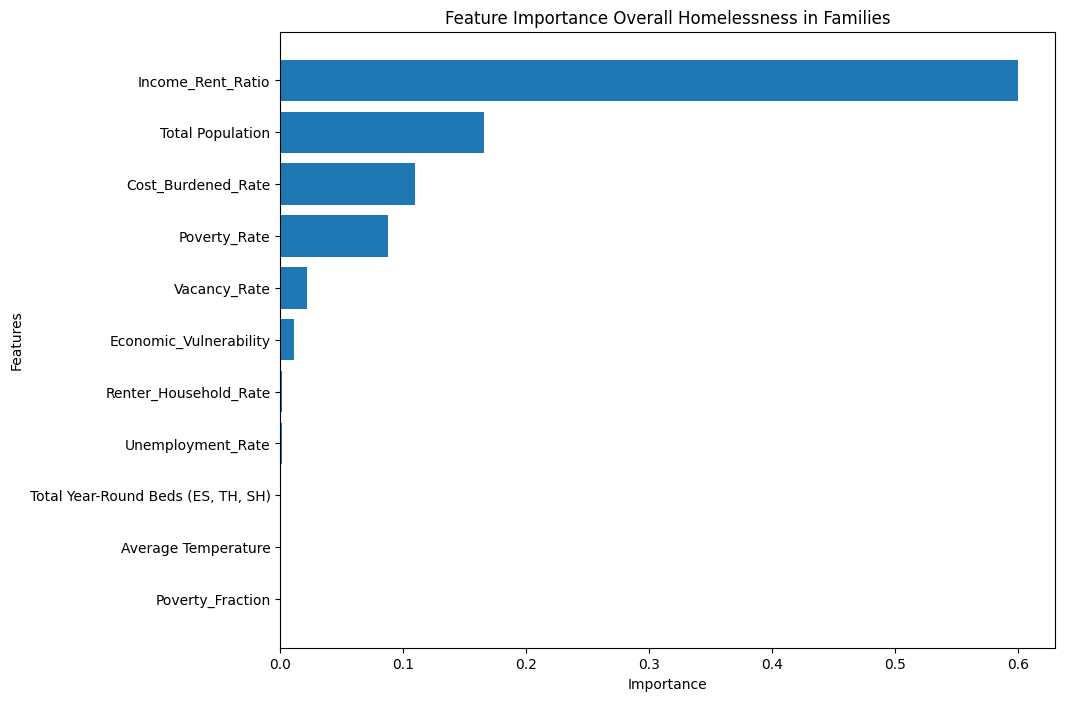

In [8]:
feature_importance = model.feature_importances_
sorted_idx = feature_importance.argsort()  # Sort in ascending order

# Plot sorted feature importances
plt.figure(figsize=(10, 8))
plt.barh(X.columns[sorted_idx], feature_importance[sorted_idx])
plt.title("Feature Importance Overall Homelessness in Families")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


## Descriptive Statistics

In [9]:
descriptive_stats = pd.DataFrame({
    'Mean': data.mean(),
    'Median': data.median(),
    'Minimum': data.min(),
    'Maximum': data.max(),
    'IQR': data.quantile(0.75) - data.quantile(0.25)
}).round(2)

print(descriptive_stats)


                                                       Mean      Median  \
Total Population                                  782603.05   465580.00   
Median Gross Rent                                 187976.35   105417.00   
Median Household Income                         10914400.85  6339523.50   
Poverty_Rate                                          14.03       13.71   
Vacancy_Rate                                          12.43       10.91   
Renter_Household_Rate                                 35.09       33.31   
Cost_Burdened_Rate                                    46.68       46.54   
Unemployment_Rate                                      7.63        7.24   
Total Year-Round Beds (ES, TH, SH)                   810.88      435.00   
Average Temperature                                   34.55       33.90   
Overall Homeless                                    3103.45      657.00   
Overall Homeless Individuals                        2024.25      429.00   
Overall Homeless People i